# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ.**

1. Множество выпукло: это надграфик выпуклой функции $u\mapsto u^2$. Действительно, для двух допустимых точек $x,y$ и $\theta\in[0,1]$:
$$((1-\theta)x_1+\theta y_1)^2\le(1-\theta)x_1^2+\theta y_1^2\le(1-\theta)x_2+\theta y_2.$$
Значит, их выпуклая комбинация также допустима.

2. Множество выпукло при любых $A,b$: это прообраз единичного евклидова шара при аффинном отображении. Для $z=(1-\theta)x+\theta y$ неравенство треугольника даёт
$$\|Az-b\|_2=\|(1-\theta)(Ax-b)+\theta(Ay-b)\|_2\le(1-\theta)\|Ax-b\|_2+\theta\|Ay-b\|_2\le1.$$
Полный ранг $A$ не требуется.

3. Множество невыпукло. Точки $(1,0)$ и $(-1,0)$ принадлежат ему, но их середина $(0,0)$ имеет норму $0<1$.

**(б)**

**Ответ.**

1. Гессиан постоянен:
$$\nabla^2f=\begin{pmatrix}2&a\\a&2\end{pmatrix},\qquad \lambda_1=2+a,\quad\lambda_2=2-a.$$
По критерию второго порядка функция **выпукла при $|a|\le2$** и **строго выпукла при $|a|<2$**. При $a=2$ имеем $f=(x_1+x_2)^2$, а при $a=-2$ — $f=(x_1-x_2)^2$: вдоль соответствующей прямой функция постоянна, поэтому строгой выпуклости нет. При $|a|>2$ одно собственное число отрицательно.

2. Для $g(x)=x_1^2x_2^2$:
$$\nabla^2g(x)=\begin{pmatrix}2x_2^2&4x_1x_2\\4x_1x_2&2x_1^2\end{pmatrix}.$$
В точке $(1,1)$ собственные числа равны $6$ и $-2$, поэтому $g$ **невыпукла**. Есть и контрпример по определению: $g(1,0)=g(0,1)=0$, но $g(1/2,1/2)=1/16>0$.

In [2]:
for a_value in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    H = np.array([[2.0, a_value], [a_value, 2.0]])
    eig = np.linalg.eigvalsh(H)
    print(f"a = {a_value:4.1f}: eigenvalues = {eig}, "
          f"convex = {eig.min() >= -1e-12}, strictly convex = {eig.min() > 1e-12}")

H_g = np.array([[2.0, 4.0], [4.0, 2.0]])
print("Eigenvalues of Hessian g at (1, 1):", np.linalg.eigvalsh(H_g))

a = -3.0: eigenvalues = [-1.  5.], convex = False, strictly convex = False
a = -2.0: eigenvalues = [0. 4.], convex = True, strictly convex = False
a = -1.0: eigenvalues = [1. 3.], convex = True, strictly convex = True
a =  0.0: eigenvalues = [2. 2.], convex = True, strictly convex = True
a =  1.0: eigenvalues = [1. 3.], convex = True, strictly convex = True
a =  2.0: eigenvalues = [0. 4.], convex = True, strictly convex = False
a =  3.0: eigenvalues = [-1.  5.], convex = False, strictly convex = False
Eigenvalues of Hessian g at (1, 1): [-2.  6.]


**(в)**

**Ответ.**

1. $\|Ax-b\|_2$ выпукла как композиция нормы с аффинным отображением; $\|x\|_\infty$ также является выпуклой нормой. Их сумма с коэффициентом $\lambda\ge0$ **выпукла**. В общем случае она **негладкая**: при $A=1,b=0,\lambda=0$ получается $|x|$ с изломом в нуле. У нормы $\|x\|_\infty$ также возможны изломы при смене максимальной по модулю координаты. В отдельных вырожденных случаях функция может быть гладкой, например постоянной.

2. Каждая $(a_i^\top x-b_i)^2$ выпукла как композиция выпуклого квадрата с аффинным отображением (её гессиан $2a_i a_i^\top\succeq0$). Поточечный максимум выпуклых функций **выпуклый**. Он **не обязательно гладкий**: $\max\{(x-1)^2,(x+1)^2\}=x^2+2|x|+1$ имеет излом при $x=0$. Если максимум всюду реализуется одной функцией или активные градиенты совпадают, гладкость возможна.

3. $e^{-\|x\|_2^2}$ **гладкая ($C^\infty$), но невыпуклая**. Правило композиции с неубывающей выпуклой функцией неприменимо: внутренняя функция $-\|x\|_2^2$ вогнута. Более того,
$$\nabla^2f(x)=e^{-\|x\|_2^2}(4xx^\top-2I),\qquad\nabla^2f(0)=-2I\prec0.$$
Контрпример: для единичного вектора $e_1$ имеем $f(e_1)=f(-e_1)=e^{-1}$, но $f(0)=1>e^{-1}$.

**(г)**

**Ответ.**

**(а) Ближайшая точка прямой.** Выпуклая QP: цель $\tfrac12\|x-(1,2,3)\|_2^2$ строго выпукла (гессиан $I$), равенства $x_1+x_2+x_3=1$ и $x_1-x_3=0$ аффинны; неравенств нет. Допустимое множество — аффинная прямая.

**(б) Диета.** Выпуклая LP: цель $c^\top x$ аффинна, неравенства $Ax-b\ge0$ и $x\ge0$ аффинны (следовательно, вогнуты), равенств нет. Допустимое множество — пересечение полупространств.

**(в) Прямоугольник.** В исходной формулировке с полуосями $u,v\ge0$ получаем $\min -4uv$ при $u^2+v^2\le1$. Равенств нет; функции неравенств $1-u^2-v^2,u,v$ вогнуты, но цель невыпукла: её гессиан $\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$ имеет собственные числа $-4,4$. Это невыпуклая QCQP. Нарушение выпуклости происходит и внутри допустимого множества: в направлении $(1,1)$ около $(1/2,1/2)$ вторая производная отрицательна.

Эту задачу можно переформулировать выпукло: для $u,v>0$ минимизировать $-\log u-\log v$ при тех же ограничениях. Логарифм монотонен, поэтому максимизатор площади тот же; прямоугольники нулевой площади оптимальными не бывают. При переменных $U=u^2,V=v^2>0$ аналогично получаем цель $-\log U-\log V$ и линейное ограничение $U+V\le1$.

**(г) Подгонка синуса.** Гладкая безусловная NLP с целью $\tfrac12\sum_i(x_1\sin(x_2t_i+x_3)-y_i)^2$. Равенств и неравенств нет, но цель в общем случае невыпукла по частоте и фазе: при фиксированных ненулевой амплитуде и частоте она периодична и обычно непостоянна по фазе; непостоянная периодическая функция на $\mathbb R$ не может быть выпуклой. Наличие квадратов невязок не гарантирует выпуклость, когда сами невязки нелинейны по параметрам.

**(д) Чебышёвская подгонка.** Цель $\max_i|a_i^\top x-b_i|$ выпукла как максимум модулей аффинных функций; ограничений нет. С дополнительной переменной $s$ получаем выпуклую LP:
$$\min_{x,s}s,\qquad s-a_i^\top x+b_i\ge0,\quad s+a_i^\top x-b_i\ge0\quad\forall i.$$
Цель и все неравенства аффинны; равенств нет.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ.** Цель $f(x)=\tfrac12\|x-p\|^2$ строго выпукла, а полупространство выпукло. Поэтому условие оптимальности необходимо и достаточно, а решение единственно.

1. Если бы $a^\top x^*<b$, все достаточно малые направления из $x^*$ были бы допустимы. Подставляя $y=x^*\pm\varepsilon v$ для любого $v$, получили бы $(x^*-p)^\top v=0$, то есть $x^*=p$. Это невозможно, поскольку $p$ недопустима. Следовательно, $a^\top x^*=b$.

2. Для любого $v$ с $a^\top v=0$ обе точки $x^*\pm v$ лежат на границе. Условие оптимальности даёт одновременно $(x^*-p)^\top v\ge0$ и $-(x^*-p)^\top v\ge0$. Значит, $x^*-p$ ортогонален всем таким $v$ и коллинеарен $a$: $x^*-p=-\mu a$.

3. Подставляя в равенство границы, получаем
$$a^\top p-\mu\|a\|^2=b,\qquad\mu=\frac{a^\top p-b}{\|a\|^2}>0,$$
откуда
$$\boxed{x^*=p-\frac{a^\top p-b}{\|a\|^2}a}.$$

4. Для любого допустимого $y$:
$$(x^*-p)^\top(y-x^*)=-\mu(a^\top y-b)=\mu(b-a^\top y)\ge0.$$
Это доказывает оптимальность. Для заданных данных $\mu=7/12$ и
$$x^*=\left(\frac{29}{12},-\frac16,\frac{13}{12}\right),\qquad f(x^*)=\frac{49}{48}.$$
Если бы $p$ уже была допустима, её проекция совпадала бы с $p$.

**Численная проверка (пункты 2 и 3)**

In [4]:
norm_a_sq = a @ a
x_formula = p - ((a @ p - b) / norm_a_sq) * a

projection_result = minimize(
    lambda x: 0.5 * np.sum((x - p) ** 2),
    x0=np.zeros_like(p),
    jac=lambda x: x - p,
    method="SLSQP",
    constraints={"type": "ineq", "fun": lambda x: b - a @ x,
                 "jac": lambda x: -a},
    options={"ftol": 1e-12, "maxiter": 1000},
)
assert projection_result.success, projection_result.message
assert b - a @ projection_result.x >= -1e-9
assert np.allclose(projection_result.x, x_formula, atol=1e-8, rtol=0)
print("Formula:", x_formula)
print("SLSQP: ", projection_result.x)
print("Distance between solutions:", np.linalg.norm(projection_result.x - x_formula))
print("Objective:", projection_result.fun)
print("Constraint residual b - a @ x:", b - a @ projection_result.x)

# Произвольная касательная компонента и неотрицательный запас до границы.
# Часть точек оставляем на границе, чтобы проверить и равенство нулю.
normal = a / np.linalg.norm(a)
z = rng.normal(size=(2000, len(a)))
tangent = z - np.outer(z @ normal, normal)
slack = rng.exponential(scale=2.0, size=2000)
slack[:200] = 0.0
feasible_y = x_formula + tangent - np.outer(slack, normal)
assert np.all(feasible_y @ a <= b + 1e-10)

condition_opt = (feasible_y - x_formula) @ (x_formula - p)
x_bad = np.zeros_like(p)
assert a @ x_bad <= b
condition_bad = (feasible_y - x_bad) @ (x_bad - p)
print("Minimum optimality expression at projection:", condition_opt.min())
print("Minimum optimality expression at x = 0:", condition_bad.min())
print("Number of negative values at x = 0:", np.sum(condition_bad < -1e-10))
assert condition_opt.min() >= -1e-10
assert condition_bad.min() < -1e-3

# Один отрицательный результат даёт конкретное допустимое направление спуска.
y_witness = feasible_y[np.argmin(condition_bad)]
direction = y_witness - x_bad
step = min(0.1, -(x_bad - p) @ direction / (direction @ direction))
x_step = x_bad + step * direction
assert a @ x_step <= b + 1e-10
assert 0.5 * np.sum((x_step - p) ** 2) < 0.5 * np.sum((x_bad - p) ** 2)
print("Objective at x = 0 and after feasible step:",
      0.5 * np.sum((x_bad - p) ** 2), 0.5 * np.sum((x_step - p) ** 2))

Formula: [ 2.41666667 -0.16666667  1.08333333]
SLSQP:  [ 2.41666667 -0.16666667  1.08333333]
Distance between solutions: 8.308148362110449e-16
Objective: 1.0208333333333348
Constraint residual b - a @ x: 2.4424906541753444e-15
Minimum optimality expression at projection: -1.3755119356370432e-15
Minimum optimality expression at x = 0: -14.939962770513349
Number of negative values at x = 0: 1711
Objective at x = 0 and after feasible step: 5.125 3.7867900439966657


**Ответ.** Формула и SLSQP дают одну и ту же точку $x^*=(29/12,-1/6,13/12)$ с $a^\top x^*=1$ и $f(x^*)=49/48\approx1.020833$. Расхождение решений обусловлено только численной точностью.

В проекции минимальное проверенное скалярное произведение равно нулю с точностью округления: для точек на границе оно нулевое, для внутренних положительное. Аналитическое доказательство выше гарантирует этот знак для **всех** допустимых точек; конечная случайная выборка сама по себе оптимальность не доказывает.

В точке $x=0$ минимум по выборке отрицателен. Найдена допустимая точка $y$, для которой $\nabla f(0)^\top(y-0)<0$: вдоль отрезка к ней достаточно малый шаг уменьшает цель. Значит, $0$ не является решением. Код также проверяет уменьшение цели на таком шаге. Это опровержение оптимальности, для которого достаточно одного контрпримера.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

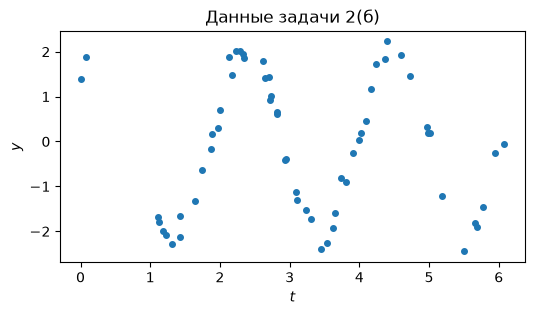

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ.**

**Модель A:** гладкая безусловная нелинейная задача наименьших квадратов (NLP), невыпуклая. У неё есть симметрии
$$f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3),\qquad f(-x_1,x_2,x_3+\pi)=f(x_1,x_2,x_3).$$
Само наличие нескольких одинаковых значений ещё не опровергает выпуклость. Здесь существенно, что при фиксированных $x_1=1,x_2=3$ зависимость от $x_3$ **периодична и непостоянна**. Выпуклая периодическая функция на всей прямой должна быть постоянной (периодичность даёт ограниченность сверху, а непостоянная выпуклая функция на $\mathbb R$ сверху не ограничена). Для данных задания непостоянство проверяется ненулевыми корреляциями $\sum y_i\sin(3t_i)$ и $\sum y_i\cos(3t_i)$: они входят в первую гармонику цели по фазе, тогда как квадрат синуса содержит только постоянную и вторую гармоники.

**Модель B:** безусловный линейный МНК, то есть выпуклая QP. Обозначим
$$D_{i1}=\sin(3t_i),\quad D_{i2}=\cos(3t_i).$$
Тогда $f_B(x)=\tfrac12\|Dx-y\|^2$, $\nabla f_B(x)=D^\top(Dx-y)$ и $\nabla^2f_B=D^\top D\succeq0$, поскольку $v^\top D^\top Dv=\|Dv\|^2\ge0$. Для данной выборки два столбца $D$ линейно независимы (проверка ниже), поэтому гессиан положительно определён, функция строго выпукла и минимум единственный.

**Мультистарт (пункт 2)**

Eigenvalues of Hessian B: [28.16194181 31.83805819]
Correlations with data: [44.83670427 40.19547863]
start     f_A          f_B       success_A success_B   ||grad_A||  ||grad_B||
 1       1.139273     1.140764    True      True     6.905e-08   3.477e-07
 2      63.824891     1.140764   False      True     5.416e-02   3.405e-14
 3       1.139273     1.140764    True      True     8.102e-09   9.875e-08
 4       1.139273     1.140764    True      True     3.145e-09   1.641e-15
 5       1.139273     1.140764    True      True     7.825e-08   1.641e-15
 6      61.497273     1.140764    True      True     1.187e-08   1.641e-15
 7      61.497273     1.140764    True      True     9.015e-08   1.641e-15
 8      64.251776     1.140764    True      True     9.513e-07   4.377e-13
 9       1.139273     1.140764    True      True     6.861e-09   1.558e-09
10      63.824891     1.140764   False      True     8.866e-02   1.641e-15
11       1.139273     1.140764   False      True     1.349e-06   7.604

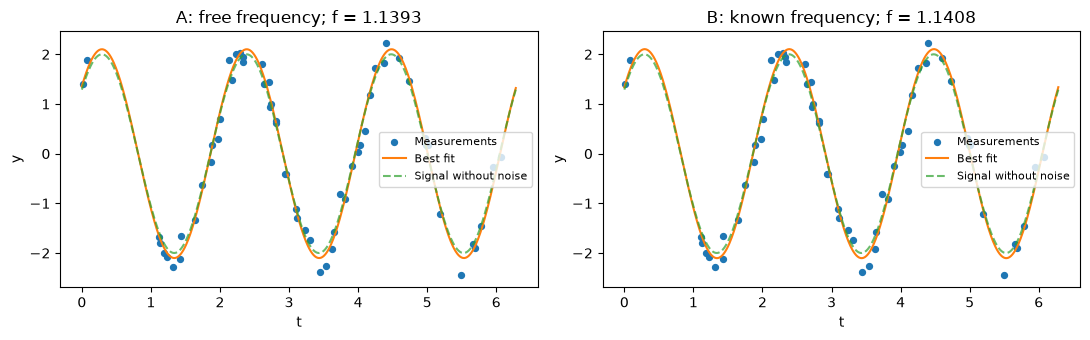

In [6]:
D = np.column_stack((np.sin(omega * t), np.cos(omega * t)))
print("Eigenvalues of Hessian B:", np.linalg.eigvalsh(D.T @ D))
print("Correlations with data:", D.T @ y)
assert np.linalg.matrix_rank(D) == 2
assert np.linalg.norm(D.T @ y) > 1e-8

def model_A(x, time):
    return x[0] * np.sin(x[1] * time + x[2])

def objective_A(x):
    residual = model_A(x, t) - y
    return 0.5 * (residual @ residual)

def gradient_A(x):
    phase = x[1] * t + x[2]
    residual = x[0] * np.sin(phase) - y
    J = np.column_stack((np.sin(phase),
                         x[0] * t * np.cos(phase),
                         x[0] * np.cos(phase)))
    return J.T @ residual

def objective_B(x):
    residual = D @ x - y
    return 0.5 * (residual @ residual)

def gradient_B(x):
    return D.T @ (D @ x - y)

results_A = [minimize(objective_A, s, jac=gradient_A, method="BFGS",
                      options={"gtol": 1e-6, "maxiter": 2000}) for s in starts]
results_B = [minimize(objective_B, s[:2], jac=gradient_B, method="BFGS",
                      options={"gtol": 1e-6, "maxiter": 2000}) for s in starts]
values_A = np.array([r.fun for r in results_A])
values_B = np.array([r.fun for r in results_B])
assert np.all(np.isfinite(values_A)) and np.all(np.isfinite(values_B))

# Совпадение значений цели проверяем с абсолютным допуском 1e-6.
tolerance = 1e-6
hits_A = np.isclose(values_A, values_A.min(), atol=tolerance, rtol=0)
hits_B = np.isclose(values_B, values_B.min(), atol=tolerance, rtol=0)
print("start     f_A          f_B       success_A success_B   ||grad_A||  ||grad_B||")
for k, (ra, rb) in enumerate(zip(results_A, results_B), 1):
    print(f"{k:2d}   {ra.fun:12.6f} {rb.fun:12.6f}   "
          f"{str(ra.success):>5}     {str(rb.success):>5}   "
          f"{np.linalg.norm(gradient_A(ra.x)):11.3e} "
          f"{np.linalg.norm(gradient_B(rb.x)):11.3e}")
for label, results in [("A", results_A), ("B", results_B)]:
    for k, result in enumerate(results, 1):
        if not result.success:
            print(f"Warning: model {label}, start {k}: {result.message}")
print(f"Fraction reaching smallest found value (atol={tolerance}): "
      f"A = {hits_A.sum()}/20 = {hits_A.mean():.0%}; "
      f"B = {hits_B.sum()}/20 = {hits_B.mean():.0%}")

best_A = results_A[np.argmin(values_A)]
best_B = results_B[np.argmin(values_B)]
x_B_exact = np.linalg.lstsq(D, y, rcond=None)[0]
f_B_exact = objective_B(x_B_exact)
assert np.allclose(values_B, f_B_exact, atol=tolerance, rtol=0)
assert np.allclose(best_B.x, x_B_exact, atol=1e-6, rtol=0)
print("Best A parameters:", best_A.x, "f =", best_A.fun)
print("B coefficients:", best_B.x, "f =", best_B.fun)
print("B direct least-squares solution:", x_B_exact)

amplitude_B = np.hypot(*best_B.x)
phase_B = np.arctan2(best_B.x[1], best_B.x[0])
x_A_from_B = np.array([amplitude_B, omega, phase_B])
assert np.allclose(model_A(x_A_from_B, t), D @ best_B.x)
assert best_A.fun <= best_B.fun + tolerance
print("A parameters representing B (amplitude, frequency, phase):", x_A_from_B)
print("Reduction in objective when frequency is free:", best_B.fun - best_A.fun)

grid = np.linspace(0, 2 * np.pi, 600)
curve_A = model_A(best_A.x, grid)
curve_B = best_B.x[0] * np.sin(omega * grid) + best_B.x[1] * np.cos(omega * grid)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, label, curve, value in zip(axes, ["A: free frequency", "B: known frequency"],
                                  [curve_A, curve_B], [best_A.fun, best_B.fun]):
    ax.scatter(t, y, s=18, label="Measurements")
    ax.plot(grid, curve, color="tab:orange", label="Best fit")
    ax.plot(grid, 2 * np.sin(3 * grid + 0.7), "--", color="tab:green",
            alpha=0.7, label="Signal without noise")
    ax.set(xlabel="t", ylabel="y", title=f"{label}; f = {value:.4f}")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Объяснение (пункт 3)**

**Ответ.** Для A наименьшее найденное значение $f_A\approx1.139273$ достигнуто в 11 из 20 запусков (55%), для B значение $f_B\approx1.140764$ — в 20 из 20 (100%); допуск сравнения значений цели $10^{-6}$. Остальные успешные запуски A дали существенно большие значения: примерно $61.497273$, $61.688171$ и $64.251776$. В модели A разные старты могут приводить к различным стационарным точкам и локальным минимумам; симметрии амплитуды, частоты и фазы также позволяют разным параметрам описывать одну кривую. Минимальное значение среди 20 запусков — **наименьшее найденное**, а не доказанный глобальный минимум.

В запусках A № 2 и № 10 получено $f\approx63.824891$, но оптимизатор не подтвердил сходимость (лимит итераций и потеря точности соответственно), а нормы градиента порядка $0.05$–$0.09$. Поэтому эти точки нельзя считать найденными минимумами. В запуске № 11 также отмечена потеря точности: значение цели совпало с лучшим в пределах допуска, но норма градиента $1.35\cdot10^{-6}$ чуть выше заданного порога. Этот запуск входит в долю 55% по значению цели; подтверждённо успешных запусков, достигших этого значения, 10 из 20. Статусы и нормы градиентов показаны в таблице.

В модели B все старты приводят к одному значению цели и одним коэффициентам с точностью допуска. По главной теореме любой локальный минимум выпуклой задачи глобален, а строгая выпуклость даёт единственность. Прямое решение через линейный МНК независимо подтверждает результат BFGS. Теорема сама по себе не обещает сходимость любого численного метода; здесь сходимость дополнительно проверена расчётом.

Пусть решение B равно $(c,d)$. По формуле сложения синуса:
$$c\sin(\omega t)+d\cos(\omega t)=R\sin(\omega t+\phi),\qquad R=\sqrt{c^2+d^2},\quad\phi=\operatorname{atan2}(d,c).$$
Поэтому соответствующие параметры A — $(R,3,\phi)$. Численно $c\approx1.623427$, $d\approx1.337808$, $R\approx2.103627$, $\phi\approx0.689243$. У лучшей найденной кривой A эквивалентные параметры с положительной амплитудой и частотой — примерно $(2.101393,2.996691,0.700264)$. Если $R=0$, фазу можно выбрать произвольно.

Модель A содержит все кривые B и дополнительно позволяет менять частоту, поэтому её глобальное минимальное значение не больше минимума B. В данном эксперименте выигрыш A составляет лишь $f_B-f_A\approx0.001491$: свободная частота частично подстраивается под шум. Меньшая ошибка на обучающей выборке не гарантирует лучшего восстановления истинного сигнала или прогноза. При этом A сложнее решать надёжно из-за невыпуклости; B использует известную частоту и имеет единственное глобальное решение.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ.** Предполагаем $\Omega\ne\varnothing$. Для непустого замкнутого выпуклого множества в $\mathbb R^n$ проекция существует и единственна: цель коэрцитивна и строго выпукла.

Положим $u=P(p)$, $v=P(q)$. Условия оптимальности с пробными точками $v$ и $u$ соответственно дают
$$(u-p)^\top(v-u)\ge0,\qquad(v-q)^\top(u-v)\ge0.$$
Обозначим $d=u-v$ и сложим неравенства:
$$\big[(v-q)-(u-p)\big]^\top d\ge0
\quad\Longrightarrow\quad
\|d\|^2\le(p-q)^\top d\le\|p-q\|\,\|d\|.$$
Последнее неравенство — Коши–Буняковского. При $d=0$ утверждение очевидно; иначе делим на $\|d\|$ и получаем
$$\boxed{\|P(p)-P(q)\|\le\|p-q\|}.$$

Ниже проверяем 1000 случайных пар в $\mathbb R^3$ для единичного шара и куба $[-1,1]^3$. Отсутствие нарушений в выборке согласуется с доказательством; сама выборка не заменяет доказательство для всех пар.

In [7]:
pairs_p = rng.normal(scale=2.0, size=(1000, 3))
pairs_q = rng.normal(scale=2.0, size=(1000, 3))

def project_ball(points):
    return points / np.maximum(1.0, np.linalg.norm(points, axis=1, keepdims=True))

def project_cube(points):
    return np.clip(points, -1.0, 1.0)

original_distances = np.linalg.norm(pairs_p - pairs_q, axis=1)
for name, projector in [("Ball", project_ball), ("Cube", project_cube)]:
    projected_p = projector(pairs_p)
    projected_q = projector(pairs_q)
    distances = np.linalg.norm(projected_p - projected_q, axis=1)
    violation = distances - original_distances
    ratio = np.divide(distances, original_distances,
                      out=np.zeros_like(distances), where=original_distances > 0)
    print(f"{name}: pairs = {len(pairs_p)}, "
          f"violations = {np.sum(violation > 1e-12)}, "
          f"max(distance after - distance before) = {violation.max():.3e}, "
          f"max ratio = {ratio.max():.6f}")
    assert np.all(distances <= original_distances + 1e-12)
    if name == "Ball":
        assert np.all(np.linalg.norm(projected_p, axis=1) <= 1 + 1e-12)
    else:
        assert np.all(np.abs(projected_p) <= 1)

Ball: pairs = 1000, violations = 0, max(distance after - distance before) = 0.000e+00, max ratio = 1.000000
Cube: pairs = 1000, violations = 0, max(distance after - distance before) = 0.000e+00, max ratio = 1.000000


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).